In [1]:
from spd.models.component_utils import (
    calc_causal_importances,
    calc_stochastic_masks,
    # calc_mask_l_zero,
    # calc_masks,
    # calc_random_masks,
    component_activation_statistics,
)
from spd.models.components import EmbeddingComponent, Gate, GateMLP, LinearComponent
from transformers import AutoTokenizer
import torch
from spd.models.component_model import ComponentModel
from datasets import load_dataset
from torch.utils.data import DataLoader
from tqdm import tqdm
from collections import defaultdict

device = "cuda" if torch.cuda.is_available() else "cpu"
# model_path = "out/last_mlp/model_50000.pth"
# model_path = "out/decent_run/model_50000.pth"
# model_path = "out/decent_run_100k/model_100000.pth"
# model_path = "out/pnorm=0.1_C=30_lr=0.0001_20250708_155943_838/model_15000.pth"
# model_path = "out/pnorm=0.1_C=100_lr=0.0001_20250708_155943_838/model_15000.pth"
# model_path = "out/pnorm=0.1_C=100_lr=0.0001_20250708_163904_453/model_15000.pth"
model_path = "out/pnorm=0.1_C=200_lr=0.0001_20250708_171815_532/model_15000.pth"

# 1.0
# model_path = "out/pnorm=0.1_C=200_lr=0.0001_20250708_171815_532/model_15000.pth"



# Now let's do the same but w/ Pnorm =2.0
# model_path = "out/pnorm=2.0_C=30_lr=0.0001_20250708_160436_407/model_15000.pth"
# spd/experiments/lm/out/pnorm=2.0_C=100_lr=0.0001_20250708_164357_284
# model_path = "out/pnorm=2.0_C=200_lr=0.0001_20250708_172312_539/model_15000.pth"
model, config, out_dir = ComponentModel.from_pretrained(model_path)
model.to(device)
model.requires_grad_(False)
model_name = "roneneldan/TinyStories-1M"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

# Create dataloader
dataset = load_dataset("roneneldan/TinyStories", split="train[:10_000]")

C = list(model.components.values())[0].A.shape[-1]
feature_range = 30
assert feature_range <= C, f"feature_range must be less than or equal to C"
# Track specific components
target_modules = {
    "transformer.h.3.mlp.c_fc": [i for i in range(feature_range)],  # module: component_idx
}
use_gate_outputs = True # ie whether to sigmoid or not

all_keys = list(model.components.keys())
for key in target_modules.keys():
    assert key.replace(".", "-") in all_keys, f"Key {key} not in {all_keys}"
# # Track specific components
# target_modules = {
#     "transformer.h.7.mlp.c_fc": [i for i in range(20)],  # Track components 0-4
#     "transformer.h.7.mlp.c_proj": [i for i in range(20)]  # Track specific components
# }

def collate_fn(examples):
    texts = [ex['text'] for ex in examples]
    tokenized = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=64,
        return_tensors='pt'
    )
    return tokenized

dataloader = DataLoader(
    dataset,
    batch_size=32,
    collate_fn=collate_fn,
    shuffle=False
)
def gather_component_activations_indexed(
    model: ComponentModel,
    tokenizer: AutoTokenizer,
    dataloader: DataLoader,
    device: str = "cuda",
    max_datapoints: int = 10000,
    target_modules: dict[str, list[int]] = None,  # {"module_name": [comp_idx1, comp_idx2, ...]}
    use_gate_outputs: bool = False,
) -> tuple[dict[str, torch.Tensor], torch.Tensor]:
    """
    Gather component activations with fully batched processing.
    
    Returns:
        - Dict mapping module_name -> tensor of shape [n_datapoints, seq_len, n_tracked_components]
        - token_sequences: Tensor of shape [n_datapoints, seq_len]
    """
    # Get module names and components
    module_comp = [key.replace('-', '.') for key in model.components.keys()]
    components = {
        k.removeprefix("components.").replace("-", "."): v for k, v in model.components.items()
    }
    As = {module_name: components[module_name].A for module_name in components}
    gates = {
        k.removeprefix("gates.").replace("-", "."): v for k, v in model.gates.items()
    }
    # If target_modules not specified, track all
    if target_modules is None:
        target_modules = {module_name: None for module_name in module_comp}
    
    # Pre-allocate storage
    seq_len = 64  # from your config
    
    # Storage for activations and tokens
    activations_storage = {}
    # for module_name, comp_indices in target_modules.items():
    #     if comp_indices is not None:
    #         n_components = len(comp_indices)
    #     else:
    #         # Get number of components from model
    #         n_components = components[module_name].A.shape[0]
        # activations_storage[module_name] = []
    activations_storage = defaultdict(list)
    token_sequences = []
    
    total_processed = 0
    
    with torch.no_grad():
        for batch_idx, batch in tqdm(enumerate(dataloader)):
            # print(f"Batch {batch_idx}")
            input_ids = batch['input_ids'].to(device)
            batch_size = input_ids.shape[0]
            
            if batch_idx*batch_size >= max_datapoints:
                break
                
            
            # Determine how many to process
            
            # Store token sequences
            # token_sequences[total_processed:total_processed + n_to_process] = input_ids[:].cpu()
            token_sequences.append(input_ids.cpu())
            # Get activations
            _, pre_weight_acts = model.forward_with_pre_forward_cache_hooks(
                input_ids,
                module_names=module_comp
            )
            
            # Calculate component activations

            # causal_importances, _ , gate_outputs = calc_causal_importances(
            causal_importances_tuple = calc_causal_importances(
                pre_weight_acts=pre_weight_acts, As=As, gates=gates, detach_inputs=False, return_gate_outputs=use_gate_outputs
            )
            if use_gate_outputs:
                _, _, causal_importances = causal_importances_tuple #actually the gate outputs
            else:
                causal_importances, _ = causal_importances_tuple

            
            # Process target modules
            for module_name, comp_indices in target_modules.items():
                if module_name not in causal_importances:
                    continue
                
                # Get activations: [batch_size, seq_len, n_components]
                acts = causal_importances[module_name]
                
                if comp_indices is not None:
                    # Index into specific components
                    acts = acts[:, :, comp_indices]
                
                # Store
                # activations_storage[module_name][total_processed:total_processed] = acts.cpu()
                activations_storage[module_name].append(acts.cpu())
            
            
            # Clear GPU memory
            del input_ids, pre_weight_acts, causal_importances
            torch.cuda.empty_cache()
    
    print("\nStacking results...")
    token_sequences = torch.cat(token_sequences, dim=0)
    
    final_activations = {}
    for module_name, acts_list in activations_storage.items():
        if acts_list:  # Check if we have any activations
            activations_storage[module_name] = torch.cat(acts_list, dim=0)
            print(f"{module_name}: stacked shape = {activations_storage[module_name].shape}")
        else:
            print(f"WARNING: No activations collected for {module_name}")
    
    return activations_storage, token_sequences

# Example usage:
print("Gathering component activations...")


activations_storage, token_sequences = gather_component_activations_indexed(
    model=model,
    tokenizer=tokenizer,
    dataloader=dataloader,
    device=device,
    max_datapoints=10_000,
    target_modules=target_modules,
    use_gate_outputs=use_gate_outputs, 
)

# Print shapes``
print(f"\nToken sequences shape: {token_sequences.shape}")
for module_name, acts in activations_storage.items():
    print(f"{module_name} activations shape: {acts.shape}")


/workspace/Stochastic_Parameter_Decomposition/spd_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-07-09 21:19:10 - INFO - PyTorch version 2.6.0+cu124 available.


Gathering component activations...


313it [00:04, 67.20it/s]


Stacking results...
transformer.h.3.mlp.c_fc: stacked shape = torch.Size([10000, 64, 30])

Token sequences shape: torch.Size([10000, 64])
transformer.h.3.mlp.c_fc activations shape: torch.Size([10000, 64, 30])


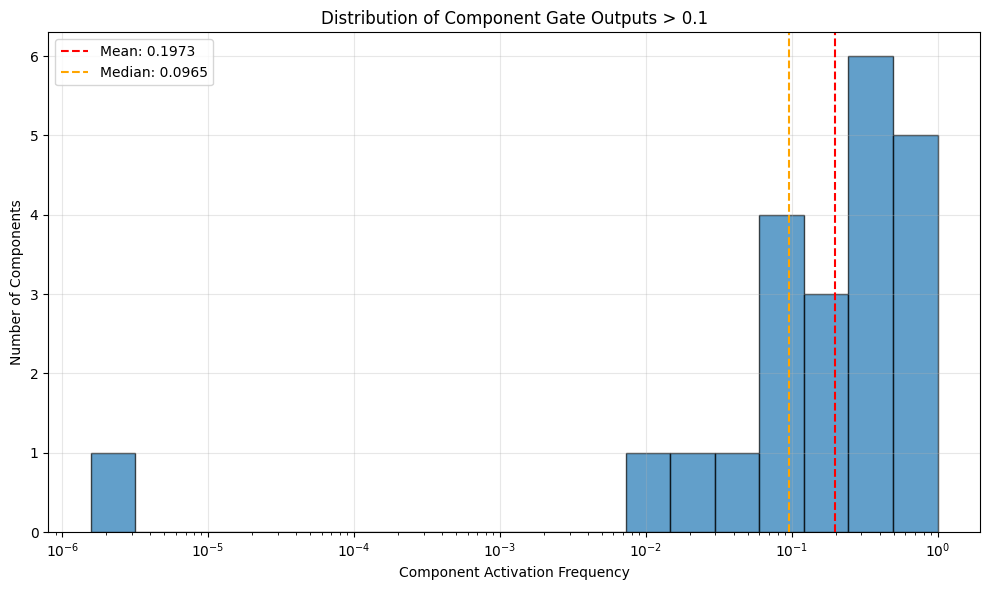

Component Gate Outputs > 0.1
Mean: 0.1973
Median: 0.0965
Min: 0.0000
Max: 0.6747
Number of components with freq > 0.1: 15
Number of components with freq > 0.01: 21


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
ones_threshold = False
threshold = 1 if ones_threshold else 0.1
# Calculate activation frequency for each feature
num_features = acts.shape[-1]  # 100 features
activation_frequencies = []
N_samples = 5000
for i in range(num_features):
    # Calculate what fraction of positions this feature is active (> 0)
    freq = (acts[:N_samples, :, i] > threshold).float().mean().item()
    activation_frequencies.append(freq)

activation_frequencies = np.array(activation_frequencies)


min_freq = activation_frequencies[activation_frequencies > 0].min()

log_bins = np.logspace(np.log10(min_freq/2), np.log10(1.0), 20)

# Create the histogram
fig, ax = plt.subplots(figsize=(10, 6))
counts, bins, patches = ax.hist(activation_frequencies, bins=log_bins, 
                               edgecolor='black', alpha=0.7)

# Set log scale for x-axis
ax.set_xscale('log')
ax.set_xlabel('Component Activation Frequency')
ax.set_ylabel('Number of Components')
ax.set_title(f'Distribution of Component Gate Outputs > {threshold}')
ax.grid(True, alpha=0.3)

# Add some statistics
mean_freq = activation_frequencies.mean()
median_freq = np.median(activation_frequencies)
ax.axvline(mean_freq, color='red', linestyle='--', label=f'Mean: {mean_freq:.4f}')
ax.axvline(median_freq, color='orange', linestyle='--', label=f'Median: {median_freq:.4f}')
ax.legend()

plt.tight_layout()
plt.show()

In [3]:
activation_frequencies

array([8.40062499e-02, 0.00000000e+00, 2.47981250e-01, 3.96253139e-01,
       5.61384380e-01, 4.96990621e-01, 0.00000000e+00, 0.00000000e+00,
       7.40906224e-02, 4.96656261e-02, 1.25109375e-01, 2.75999997e-02,
       9.07749981e-02, 0.00000000e+00, 6.16784394e-01, 0.00000000e+00,
       3.98596883e-01, 6.74737513e-01, 6.49309397e-01, 1.29465625e-01,
       0.00000000e+00, 1.11218747e-02, 1.02256253e-01, 2.10815623e-01,
       3.12499992e-06, 3.64781260e-01, 0.00000000e+00, 0.00000000e+00,
       2.66706258e-01, 3.40281248e-01])

In [4]:
def get_token_activation_stats(
    activations_storage: dict[str, torch.Tensor],
    token_sequences: torch.Tensor,
    tokenizer: AutoTokenizer,
    module_name: str,
    component_idx: int,
    activation_threshold: float = 0.1,
    top_k_tokens: int = 5,
    max_activations_to_sample: int = 1000
) -> dict:
    """
    Get statistics about which tokens most frequently activate a component.
    
    Args:
        activations_storage: Dict from gather_component_activations_indexed
        token_sequences: Token sequences tensor
        tokenizer: Tokenizer for decoding
        module_name: Which module to analyze
        component_idx: Which component index within that module
        activation_threshold: Minimum activation value to count as "activated"
        top_k_tokens: Number of top tokens to return
        max_activations_to_sample: Maximum number of activations to sample (for efficiency)
    
    Returns:
        Dict with token stats including top tokens and their activation rates
    """
    # Get activations for this component
    component_acts = activations_storage[module_name][:, :, component_idx]
    
    # Find all positions where activation > threshold (vectorized)
    activation_mask = component_acts > activation_threshold
    activated_positions = torch.nonzero(activation_mask, as_tuple=False)
    
    # If we have too many activations, sample randomly
    if len(activated_positions) > max_activations_to_sample:
        # Random sampling without replacement
        sample_indices = torch.randperm(len(activated_positions))[:max_activations_to_sample]
        activated_positions = activated_positions[sample_indices]
        sampled = True
        sample_ratio = max_activations_to_sample / activation_mask.sum().item()
    else:
        sampled = False
        sample_ratio = 1.0
    
    # Count token activations
    token_activation_counts = {}
    
    for pos in activated_positions:
        datapoint_idx, token_pos = pos[0].item(), pos[1].item()
        token_id = token_sequences[datapoint_idx, token_pos].item()
        
        # Skip padding tokens
        if token_id == 0:
            continue
            
        if token_id not in token_activation_counts:
            token_activation_counts[token_id] = 0
        token_activation_counts[token_id] += 1
    
    # Calculate statistics
    total_sampled_activations = len(activated_positions)
    total_actual_activations = activation_mask.sum().item()
    
    # Calculate what percentage of all activations each token represents
    token_activation_stats = {}
    for token_id, activation_count in token_activation_counts.items():
        # Adjust counts if we sampled
        estimated_count = activation_count / sample_ratio if sampled else activation_count
        percentage_of_activations = (activation_count / total_sampled_activations * 100 
                                   if total_sampled_activations > 0 else 0)
        token_activation_stats[token_id] = {
            'activation_count': int(estimated_count),
            'percentage_of_activations': percentage_of_activations,
            'token_text': tokenizer.decode([token_id]),
            'sampled_count': activation_count
        }
    
    # Sort by activation count (or percentage) and get top K
    sorted_tokens = sorted(
        token_activation_stats.items(),
        key=lambda x: x[1]['sampled_count'],
        reverse=True
    )[:top_k_tokens]
    
    return {
        'top_tokens': sorted_tokens,
        'total_unique_activating_tokens': len(token_activation_counts),
        'total_activations_above_threshold': int(total_actual_activations),
        'threshold': activation_threshold,
        'sampled': sampled,
        'sample_ratio': sample_ratio
    }


def visualize_top_component_activations(
    activations_storage: dict[str, torch.Tensor],
    token_sequences: torch.Tensor,
    tokenizer: AutoTokenizer,
    module_name: str,
    component_idx: int,
    top_k: int = 10,
    context_before: int = 10,
    context_after: int = 5,
    show_token_stats: bool = True,
    activation_threshold: float = 0.1,
) -> str:
    """
    Create HTML visualization for top K activations of a specific component.
    
    Args:
        activations_storage: Dict from gather_component_activations_indexed
        token_sequences: Token sequences tensor
        tokenizer: Tokenizer for decoding
        module_name: Which module to visualize
        component_idx: Which component index within that module
        top_k: Number of top activations to show
        context_before: Tokens to show before activation
        context_after: Tokens to show after activation
        show_token_stats: Whether to show token activation statistics
        activation_threshold: Threshold for counting token activations
    
    Returns:
        HTML string
    """
    # Get activations for this component
    component_acts = activations_storage[module_name][:, :, component_idx]
    
    # Find top K activations
    flat_acts = component_acts.flatten()
    top_k_values, top_k_indices = torch.topk(flat_acts, k=min(top_k, flat_acts.numel()))
    
    # Convert flat indices back to (datapoint, position)
    n_datapoints, seq_len = component_acts.shape
    top_k_locations = []
    for idx in top_k_indices:
        datapoint_idx = idx // seq_len
        token_pos = idx % seq_len
        activation_value = component_acts[datapoint_idx, token_pos].item()
        top_k_locations.append((datapoint_idx.item(), token_pos.item(), activation_value))
    
    # Get activation range for this component
    nonzero_acts = component_acts[component_acts > 0]
    if len(nonzero_acts) > 0:
        min_act = nonzero_acts.min().item()
        max_act = nonzero_acts.max().item()
    else:
        min_act, max_act = 0, 1

    freq = (component_acts > 0.1).float().mean().item()
    freq_one = (component_acts > 1).float().mean().item()
    freq_percent = freq * 100
    freq_one_percent = freq_one * 100
    
    # Start building HTML
    html_parts = [
        '<div style="font-family: monospace; background-color: transparent; padding: 20px;">',
        f'<h2>Component {component_idx} - Module: {module_name}</h2>',
        f'<h3>Activation Frequency > 0.1: {freq_percent:.2f}%  | Freq > 1: {freq_one_percent:.2f}%</h3>',
    ]
    
    # Add token statistics if requested
    if show_token_stats and freq_percent > 0:  # Only show if component is not dead
        # Get stats for both thresholds
        token_stats_01 = get_token_activation_stats(
            activations_storage=activations_storage,
            token_sequences=token_sequences,
            tokenizer=tokenizer,
            module_name=module_name,
            component_idx=component_idx,
            activation_threshold=0.1,
            top_k_tokens=5,
            max_activations_to_sample=1000
        )
        
        token_stats_10 = get_token_activation_stats(
            activations_storage=activations_storage,
            token_sequences=token_sequences,
            tokenizer=tokenizer,
            module_name=module_name,
            component_idx=component_idx,
            activation_threshold=1.0,
            top_k_tokens=5,
            max_activations_to_sample=1000
        )
        
        html_parts.append('<div style="margin-bottom: 20px;">')
        html_parts.append('<div style="display: flex; gap: 20px;">')
        
        # Table for threshold > 0.1
        html_parts.append('<div style="flex: 1; background-color: rgba(0, 0, 0, 0.05); padding: 10px; border-radius: 5px; border: 1px solid rgba(0, 0, 0, 0.1);">')
        html_parts.append(f'<h4>Top Tokens (threshold > 0.1):</h4>')
        
        if token_stats_01['top_tokens']:
            html_parts.append('<table style="border-collapse: collapse; margin-top: 10px; background-color: rgba(255, 255, 255, 0.0); width: 100%;">')
            html_parts.append('<tr><th style="padding: 5px; text-align: left;">Token</th>')
            html_parts.append('<th style="padding: 5px; text-align: left;">%</th>')
            html_parts.append('<th style="padding: 5px; text-align: left;">Count</th></tr>')
            
            total_acts = token_stats_01['total_activations_above_threshold']
            for token_id, stats in token_stats_01['top_tokens']:
                token_text = stats['token_text']
                token_display = repr(token_text)[1:-1]
                percentage = stats['percentage_of_activations']
                count_text = f"{stats['activation_count']}/{total_acts}"
                
                html_parts.append(f'<tr>')
                html_parts.append(f'<td style="padding: 5px; border: 1px solid rgba(0, 0, 0, 0.2);"><code>{token_display}</code></td>')
                html_parts.append(f'<td style="padding: 5px; border: 1px solid rgba(0, 0, 0, 0.2);">{percentage:.1f}%</td>')
                html_parts.append(f'<td style="padding: 5px; border: 1px solid rgba(0, 0, 0, 0.2);">{count_text}</td>')
                html_parts.append(f'</tr>')
            
            html_parts.append('</table>')
            html_parts.append(f'<div style="margin-top: 10px; font-size: 0.9em; color: #333;">')
            html_parts.append(f'Unique tokens: {token_stats_01["total_unique_activating_tokens"]}<br>')
            html_parts.append(f'Total acts > 0.1: {total_acts}')
            if token_stats_01['sampled']:
                html_parts.append(f'<br><em>Sampled {int(token_stats_01["sample_ratio"]*100)}%</em>')
            html_parts.append('</div>')
        else:
            html_parts.append('<div>No tokens activate above threshold</div>')
        
        html_parts.append('</div>')
        
        # Table for threshold > 1.0
        html_parts.append('<div style="flex: 1; background-color: rgba(0, 0, 0, 0.05); padding: 10px; border-radius: 5px; border: 1px solid rgba(0, 0, 0, 0.1);">')
        html_parts.append(f'<h4>Top Tokens (threshold > 1.0):</h4>')
        
        if token_stats_10['top_tokens']:
            html_parts.append('<table style="border-collapse: collapse; margin-top: 10px; background-color: rgba(255, 255, 255, 0.0); width: 100%;">')
            html_parts.append('<tr><th style="padding: 5px; text-align: left;">Token</th>')
            html_parts.append('<th style="padding: 5px; text-align: left;">%</th>')
            html_parts.append('<th style="padding: 5px; text-align: left;">Count</th></tr>')
            
            total_acts = token_stats_10['total_activations_above_threshold']
            for token_id, stats in token_stats_10['top_tokens']:
                token_text = stats['token_text']
                token_display = repr(token_text)[1:-1]
                percentage = stats['percentage_of_activations']
                count_text = f"{stats['activation_count']}/{total_acts}"
                
                html_parts.append(f'<tr>')
                html_parts.append(f'<td style="padding: 5px; border: 1px solid rgba(0, 0, 0, 0.2);"><code>{token_display}</code></td>')
                html_parts.append(f'<td style="padding: 5px; border: 1px solid rgba(0, 0, 0, 0.2);">{percentage:.1f}%</td>')
                html_parts.append(f'<td style="padding: 5px; border: 1px solid rgba(0, 0, 0, 0.2);">{count_text}</td>')
                html_parts.append(f'</tr>')
            
            html_parts.append('</table>')
            html_parts.append(f'<div style="margin-top: 10px; font-size: 0.9em; color: #333;">')
            html_parts.append(f'Unique tokens: {token_stats_10["total_unique_activating_tokens"]}<br>')
            html_parts.append(f'Total acts > 1.0: {total_acts}')
            if token_stats_10['sampled']:
                html_parts.append(f'<br><em>Sampled {int(token_stats_10["sample_ratio"]*100)}%</em>')
            html_parts.append('</div>')
        else:
            html_parts.append('<div>No tokens activate above threshold</div>')
        
        html_parts.append('</div>')
        html_parts.append('</div>')
        html_parts.append('</div>')
    
    # Add color bar
    html_parts.append('<div style="margin-bottom: 20px;">')
    html_parts.append('<span>Activation strength: </span>')
    html_parts.append(make_colorbar(min_act, max_act))
    html_parts.append('</div>')
    
    # Process each top activation
    for rank, (datapoint_idx, token_pos, act_value) in enumerate(top_k_locations):
        html_parts.append(f'<div style="margin-bottom: 15px; padding-left: 0;">')
        
        # Get tokens for this datapoint
        tokens = token_sequences[datapoint_idx]
        
        # Determine context window
        start_pos = max(0, token_pos - context_before)
        end_pos = min(len(tokens), token_pos + context_after + 1)
        
        # Get activations for this sequence
        seq_acts = component_acts[datapoint_idx]
        
        # Build token display
        token_html = []
        for pos in range(start_pos, end_pos):
            token = tokens[pos].item()
            if token == 0:  # Skip padding
                continue
                
            token_text = tokenizer.decode([token])
            activation = seq_acts[pos].item() if pos < len(seq_acts) else 0
            
            # Determine background color
            if activation > 0:
                # Scale activation to color intensity
                intensity = activation / max_act if max_act > 0 else 0
                # Blue color with varying intensity
                blue_value = 255
                red_green_value = int(255 * (1 - intensity * 0.7))  # Scale from white to blue
                bg_color = f"rgb({red_green_value}, {red_green_value}, {blue_value})"
                text_color = "black" if intensity < 0.5 else "white"
            else:
                bg_color = "white"
                text_color = "black"
            
            # Special formatting for the target position
            if pos == token_pos:
                token_html.append(
                    f'<span style="background-color: {bg_color}; color: {text_color}; '
                    f'border: 2px solid red; padding: 2px;">{token_text}</span>'
                )
            else:
                token_html.append(
                    f'<span style="background-color: {bg_color}; color: {text_color}; '
                    f'padding: 2px;">{token_text}</span>'
                )
        
        html_parts.append('<div style="margin-top: 5px;">')
        html_parts.append(''.join(token_html))
        html_parts.append('</div>')
        html_parts.append('</div>')
    
    html_parts.append('</div>')
    return ''.join(html_parts)

def make_colorbar(min_value: float, max_value: float) -> str:
    """Create a color bar showing the activation range."""
    html = []
    n_steps = 5
    
    for i in range(n_steps + 1):
        ratio = i / n_steps
        value = min_value + (max_value - min_value) * ratio
        
        # Calculate color
        blue_value = 255
        red_green_value = int(255 * (1 - ratio * 0.7))
        bg_color = f"rgb({red_green_value}, {red_green_value}, {blue_value})"
        text_color = "black" if ratio < 0.5 else "white"
        
        html.append(
            f'<span style="background-color: {bg_color}; color: {text_color}; '
            f'padding: 4px 8px; margin-right: 2px;">{value:.3f}</span>'
        )
    
    return ''.join(html)

# Example usage:
from IPython.display import display, HTML

for i in range(3):
    # Visualize component from the first tracked module
    module_name = list(activations_storage.keys())[0]
    # module_name = list(activations_storage.keys())[1]
    html = visualize_top_component_activations(
        activations_storage=activations_storage,
        token_sequences=token_sequences,
        tokenizer=tokenizer,
        module_name=module_name,
        component_idx=i,  # This is the index within the tracked components
        top_k=20,
        context_before=15,
        context_after=5,
        show_token_stats=True,  # Enable token statistics
        activation_threshold=0.1  # Threshold for counting activations
    )

    display(HTML(html))
print(f"Model path: {model_path}")

Token,%,Count
.,26.1%,15045/57647
Once,12.4%,7148/57647
upon,8.4%,4842/57647
said,5.2%,2997/57647
for,3.4%,1959/57647
Token,%,Count
"!""",25.2%,1008/4001
"?""",23.3%,932/4001
said,16.4%,656/4001
".""",10.8%,432/4001


Token,%,Count
a,17.9%,28396/158637
the,13.2%,20940/158637
there,3.5%,5552/158637
little,3.5%,5552/158637
her,3.0%,4759/158637
Token,%,Count
a,35.2%,28425/80753
the,18.4%,14858/80753
One,4.7%,3795/80753
his,4.4%,3553/80753


Model path: out/pnorm=0.1_C=200_lr=0.0001_20250708_171815_532/model_15000.pth


In [5]:
# Your handwritten text
text = "Once upon a time there was an ice-cream"
token_position = 8  # Specify which token position to analyze

# Tokenize
inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=64)
input_ids = inputs['input_ids'].to(device)

# Print tokens to help identify positions
text_list = [str(tok_idx) + ": " + tokenizer.decode(token_ids) for tok_idx, token_ids in enumerate(input_ids[0])]
print(text_list)

# Verify the token at specified position
target_token_id = input_ids[0, token_position].item()
target_token_text = tokenizer.decode([target_token_id])
print(f"\n>>> Analyzing position {token_position}: '{target_token_text}' <<<\n")

# Get activations
with torch.no_grad():
    _, pre_weight_acts = model.forward_with_pre_forward_cache_hooks(
        input_ids,
        module_names=list(target_modules.keys())
    )

# Calculate component activations
As = {module_name: model.components[f"{module_name.replace('.', '-')}"].A 
      for module_name in target_modules.keys()}
component_acts = calc_component_acts(pre_weight_acts=pre_weight_acts, As=As)

# Find top activating components AT THE SPECIFIED POSITION
top_components = []
for module_name, acts in component_acts.items():
    # acts shape: [1, seq_len, n_components]
    # Get activations only at the specified position
    acts_at_position = acts[0, token_position, :]  # [n_components]
    
    # Get top 10 components for this module at this position
    top_values, top_indices = torch.topk(acts_at_position, k=min(10, len(acts_at_position)))
    
    for idx, val in zip(top_indices, top_values):
        if val > 0:  # Only include components that actually activated
            top_components.append((module_name, idx.item(), val.item()))

# Sort by activation value
top_components.sort(key=lambda x: x[2], reverse=True)

# Create target_modules dict from the top components found
target_modules_from_top = {}
for module_name, comp_idx, _ in top_components[:10]:  # Track top 10 components
    if module_name not in target_modules_from_top:
        target_modules_from_top[module_name] = []
    target_modules_from_top[module_name].append(comp_idx)

print(f"\nGathering activations for components: {target_modules_from_top}")

# Gather activations from larger dataset
activations_storage, token_sequences = gather_component_activations_indexed(
    model=model,
    tokenizer=tokenizer,
    dataloader=dataloader,
    device=device,
    max_datapoints=1000,
    target_modules=target_modules_from_top
)

# Visualize each top component
# print("\n\nVisualizations:")
for i, (module_name, comp_idx, activation_value) in enumerate(top_components[:10]):
    # print(f"\n=== Component {comp_idx} from {module_name} ===")
    # print(f"Activation on '{target_token_text}' at position {token_position}: {activation_value:.3f}")
    
    # First show the ice-cream example
    activations_storage_single = {
        module_name: component_acts[module_name][:, :, [comp_idx]].cpu()
    }
    token_sequences_single = input_ids.cpu()
    
    html_icecream = visualize_top_component_activations(
        activations_storage=activations_storage_single,
        token_sequences=token_sequences_single,
        tokenizer=tokenizer,
        module_name=module_name,
        component_idx=0,
        top_k=1,
        context_before=30,
        context_after=30
    )
    
    # # Modify title for ice-cream example
    html_icecream = html_icecream.replace(
        f'<h2>Component 0 -', 
        f'<h2>Your example - Component {comp_idx} -'
    )
    
    display(HTML(html_icecream))
    
    # Now show top activations from the larger dataset
    # Find the index of this component in our tracked components
    comp_index_in_tracked = target_modules_from_top[module_name].index(comp_idx)
    
    html_dataset = visualize_top_component_activations(
        activations_storage=activations_storage,
        token_sequences=token_sequences,
        tokenizer=tokenizer,
        module_name=module_name,
        component_idx=comp_index_in_tracked,
        top_k=10,  # Show top 10 from dataset
        context_before=15,
        context_after=5
    )
    
    # # Modify title for dataset examples
    html_dataset = html_dataset.replace(
        f'<h2>Component {comp_index_in_tracked} -', 
        f'<h2>Top activations from dataset - Component {comp_idx} -'
    )
    
    display(HTML(html_dataset))

['0: Once', '1:  upon', '2:  a', '3:  time', '4:  there', '5:  was', '6:  an', '7:  ice', '8: -', '9: cream']

>>> Analyzing position 8: '-' <<<



NameError: name 'calc_component_acts' is not defined